In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import mnist
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [3]:
import matplotlib.pyplot as plt

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
single_image = x_train[0]

In [7]:
single_image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
single_image.shape

(28, 28)

In [9]:
single_image.max()

np.uint8(255)

In [10]:
single_image.min()

np.uint8(0)

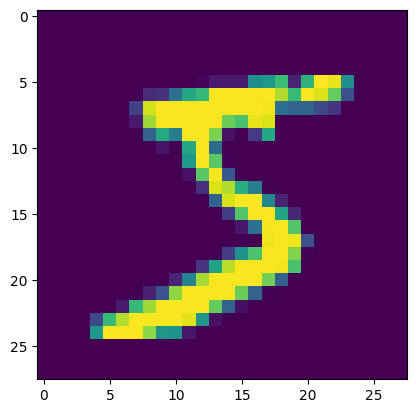

In [11]:
plt.imshow(single_image)

In [12]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [13]:
y_train.shape

(60000,)

In [14]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [15]:
y_test.shape

(10000,)

In [16]:
from tensorflow.keras.utils import to_categorical

In [17]:
y_cat_train = to_categorical(y_train)

In [18]:
y_cat_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [19]:
y_cat_train.shape

(60000, 10)

In [20]:
y_cat_test = to_categorical(y_test)

In [21]:
y_cat_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [22]:
y_cat_test.shape

(10000, 10)

In [23]:
#Normalize the data
x_train = x_train/255
x_test = x_test/255

In [24]:
x_train[0].max()

np.float64(1.0)

In [25]:
x_train[0].min()

np.float64(0.0)

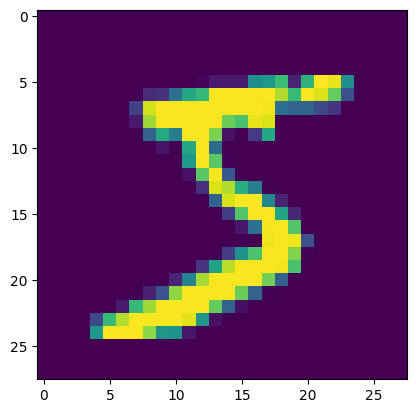

In [26]:
plt.imshow(x_train[0])

In [27]:
x_train.shape

(60000, 28, 28)

In [28]:
x_train = x_train.reshape(60000,28,28,1)

In [29]:
x_train.shape

(60000, 28, 28, 1)

In [30]:
x_test.shape

(10000, 28, 28)

In [31]:
x_test = x_test.reshape(10000,28,28,1)

In [32]:
x_test.shape

(10000, 28, 28, 1)

In [33]:
#build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [34]:
model = Sequential()

model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(28,28,1),activation = 'relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation = 'relu'))
model.add(Dense(10,activation = 'softmax'))

c:\Users\Hassan Dheriwala\OneDrive\Desktop\ppp\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss',patience = 2)

In [37]:
model.compile(loss = 'categorical_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [47]:
#Train the model
model.fit(x_train, y_cat_train, epochs = 10, validation_data=(x_test, y_cat_test),callbacks=[early_stop])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9977 - loss: 0.0065 - val_accuracy: 0.9885 - val_loss: 0.0430
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9980 - loss: 0.0054 - val_accuracy: 0.9886 - val_loss: 0.0414


In [39]:
model.metrics_names

['loss', 'compile_metrics']

In [40]:
losses = pd.DataFrame(model.history.history)

In [41]:
losses

,accuracy,loss,val_accuracy,val_loss
0,0.959267,0.137311,0.9830,0.049903
1,0.985783,0.047358,0.9845,0.042866
2,0.990767,0.029852,0.9877,0.036758
3,0.993500,0.020331,0.9844,0.045678
4,0.995517,0.013327,0.9878,0.035018
5,0.996183,0.010796,0.9877,0.039429
6,0.997567,0.007895,0.9880,0.044437


<Axes: >

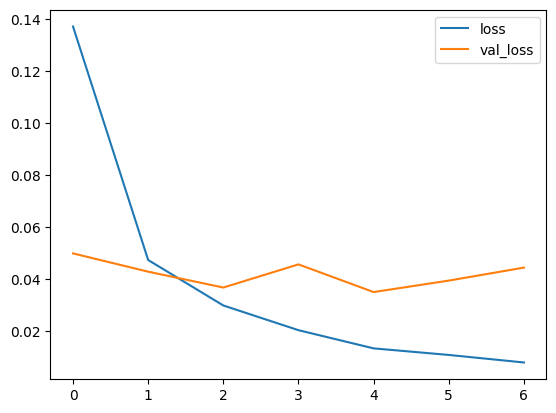

In [42]:
losses[['loss','val_loss']].plot()

<Axes: >

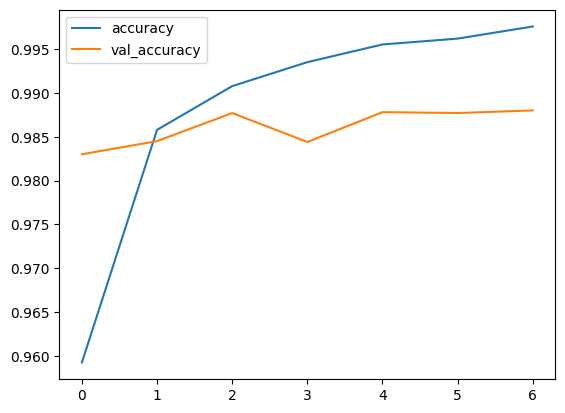

In [43]:
losses[['accuracy','val_accuracy']].plot()

In [44]:
model.metrics_names

['loss', 'compile_metrics']

In [45]:
model.evaluate(x_test,y_cat_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9880 - loss: 0.0444


[0.044436994940042496, 0.9879999756813049]

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
y_test_pred = model.predict(x_test)

313/313 [==============================] - 0s 841us/step


In [ ]:
y_test_pred.shape

(10000, 10)

In [ ]:
y_test_pred[0]

array([1.2250516e-13, 1.8890477e-10, 2.1251897e-10, 1.0303149e-09,
       1.6039456e-09, 1.4105717e-13, 3.2590024e-19, 1.0000000e+00,
       2.3006452e-10, 1.5705252e-08], dtype=float32)

In [ ]:
y_test_pred_classes = np.argmax(y_test_pred,axis = 1)

In [ ]:
y_test_pred_classes.shape

(10000,)

In [ ]:
y_test_pred_classes[0]

7

In [ ]:
print(classification_report(y_test,y_test_pred_classes))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.98       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
confusion_matrix(y_test, y_test_pred_classes)

array([[ 977,    0,    1,    1,    0,    0,    0,    0,    1,    0],
       [   0, 1133,    0,    0,    0,    0,    1,    0,    1,    0],
       [   1,    1, 1021,    0,    0,    0,    2,    6,    1,    0],
       [   0,    1,    1, 1001,    0,    5,    0,    0,    1,    1],
       [   0,    2,    0,    0,  962,    0,    6,    0,    0,   12],
       [   1,    0,    1,    6,    0,  879,    3,    0,    1,    1],
       [  10,    2,    0,    0,    2,    4,  938,    0,    2,    0],
       [   1,    5,    4,    0,    0,    0,    0, 1011,    1,    6],
       [   4,    2,    3,    1,    1,    1,    0,    2,  954,    6],
       [   2,    1,    0,    3,    2,    0,    0,    0,    1, 1000]])

In [ ]:
y_train_pred = model.predict(x_train)

1875/1875 [==============================] - 2s 810us/step


In [ ]:
y_train_pred.shape

(60000, 10)

In [ ]:
y_train_pred[0]

array([7.3219547e-14, 1.8391910e-10, 7.6630065e-13, 1.9766429e-02,
       2.0328476e-12, 9.8023349e-01, 3.5701517e-14, 5.7379202e-11,
       3.9382790e-09, 1.2478050e-07], dtype=float32)

In [ ]:
y_train_pred_classes = np.argmax(y_train_pred,axis = 1)

In [ ]:
y_train_pred_classes.shape

(60000,)

In [ ]:
y_train_pred_classes[0]

5

In [ ]:
print(classification_report(y_train,y_train_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       1.00      1.00      1.00      6742
           2       1.00      1.00      1.00      5958
           3       1.00      1.00      1.00      6131
           4       1.00      1.00      1.00      5842
           5       1.00      1.00      1.00      5421
           6       1.00      1.00      1.00      5918
           7       1.00      1.00      1.00      6265
           8       1.00      1.00      1.00      5851
           9       1.00      1.00      1.00      5949

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



In [ ]:
confusion_matrix(y_train,y_train_pred_classes)

array([[5923,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0, 6741,    0,    0,    0,    0,    0,    1,    0,    0],
       [   0,    1, 5957,    0,    0,    0,    0,    0,    0,    0],
       [   0,    1,    0, 6118,    0,    5,    0,    0,    3,    4],
       [   0,    7,    0,    0, 5820,    0,    1,    0,    0,   14],
       [   0,    1,    0,    0,    0, 5409,    5,    0,    4,    2],
       [   5,    0,    0,    0,    0,    0, 5913,    0,    0,    0],
       [   0,   18,    0,    0,    3,    0,    0, 6237,    0,    7],
       [   2,    0,    1,    0,    0,    0,    0,    0, 5847,    1],
       [   0,    3,    0,    0,    0,    0,    0,    0,    0, 5946]])

In [ ]:
#predict for inference image
inference_image = x_test[234]

In [ ]:
print(inference_image.max(),inference_image.min())

1.0 0.0


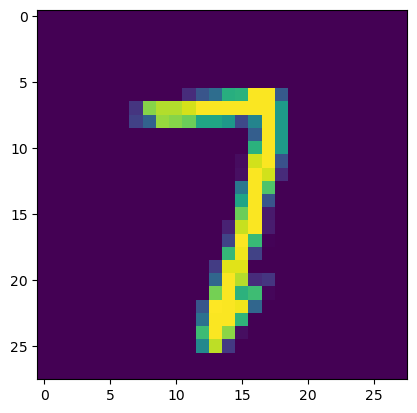

In [ ]:
plt.imshow(inference_image)

In [ ]:
inference_image.shape

(28, 28, 1)

In [ ]:
np.argmax(model.predict(inference_image.reshape(1,28,28,1)))

1/1 [==============================] - 0s 10ms/step


7

In [48]:
model.save("model.h5")

In [ ]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>
